# Гибридный поиск в агентных пайплайнах и хранилища данных

> Внимание! Материал ноутбука подходит для работы в Google Colaboratory. Мы не можем гарантировать стабильную работу кода на личных устройствах и на других системах виртуализации.

## Введение

На занятии 6 мы собрали диалоговый контур ассистента поддержки банка Сбер, и ретривер в нём был **заглушкой из пяти захардкоженных сниппетов**. Зато вокруг этой заглушки уже работало всё остальное: слоты, бюджет контекста, дисциплина цитирования версий документов. Сегодня мы меняем тело функции `retrieve` на настоящий поиск, не меняя её контракт.

### Почему одного вектора недостаточно

**Плотный (dense) поиск** ищет по смыслу и отлично переживает перефразировки: «вернуть деньги» находит документ про «возврат средств». Но он систематически промахивается на точных идентификаторах и редких терминах: номер приказа `62-Т`, код `SWIFT`, название `СберВклад`.

**Лексический (sparse) поиск** – наоборот: BM25 точно находит `62-Т` и ничего не понимает про перефразировки.

Отсюда **гибридный поиск**: две независимые ноги и слияние их выдач.

### Как сливаем выдачи

Слияние делаем через **Reciprocal Rank Fusion (RRF)** – сложение обратных рангов. Ключевое свойство: RRF работает **с рангами, а не со значениями релевантности**, поэтому ему не нужна нормализация несопоставимых шкал (BM25 даёт числа вроде 12.7, косинус – 0.83).

Альтернатива – линейное слияние с MinMax-нормализацией: даёт больше контроля, но требует калибровки под каждый корпус.

### Три особенности нашей задачи

**Русская морфология.** Запрос «списали» и документ «списание» для BM25 – **разные токены**. Банковская лексика особенно злая: *оспаривание / оспорить / оспариваемая*, *начисление / начислять / начисленный*, *списание / списать / списанная*. Без лемматизации лексическая нога теряет половину попаданий. Решаем через **pymorphy3**.

**Би-темпоральность.** У каждого тарифного сборника есть `valid_from` / `valid_to` и номер приказа; у операции клиента – своя дата. Вопрос «почему списали 250 ₽ вместо 199 ₽» имеет **два разных корректных ответа** в зависимости от даты операции. Это закрывается не моделью и не эмбеддингом, а **темпоральным предикатом в фильтре по метаданным**.

**Тарифные таблицы как задача чанкинга.** Сырой чанк `1,5 %, мин. 199 ₽` семантически бесполезен: у него нет ни строки, ни столбца таблицы. Это самое убедительное реальное обоснование **contextual retrieval**, и мы его увидим на числах.

### Оговорка про измерения

Сегодня мы смотрим на дельты score и латентности как на инженерную интуицию: «стало лучше/хуже, стало быстрее/медленнее». Словарь метрик оценки (Recall@k, nDCG, judges, датасеты) вводится на занятиях 9–12 – здесь мы к нему сознательно не переходим, чтобы не подменять инженерную работу преждевременной метрологией.

### Что мы построим за занятие

Ретривер в виде `@tool`, который на вопрос про июньскую и августовскую операцию возвращает разные корректные версии тарифа, и конвейер `BM25 → dense → RRF → cross-encoder` с логированием score и латентности каждой ступени.

## Установка зависимостей

Устанавливаем библиотеки. Нам понадобятся:
- `langchain-gigachat` – `GigaChat` (contextual retrieval, генерация ответа) и `GigaChatEmbeddings` (плотная нога)
- `langgraph` / `langchain` – граф агента и оформление ретривера как `@tool`
- `qdrant-client` – векторное хранилище в режиме `:memory:`, HNSW, фильтры по payload, Query API с `Fusion.RRF`
- `bm25s` – быстрая лексическая нога (замена кластерного Elasticsearch в Colab)
- `pymorphy3` – морфологический анализатор русского языка для лемматизации
- `sentence-transformers` – cross-encoder реранкер BGE-reranker-v2-m3
- `fakeredis` – роль сессионного хранилища с TTL без внешнего Redis

Про то, что **не** ставим: полноценный Elasticsearch/OpenSearch требует кластера, Milvus с full-text — Standalone-развёртывания, ParadeDB `pg_search` — hosted Postgres. Эти варианты разбираем как продовые, но в Colab заменяем эквивалентами.

In [ ]:
%%capture
%pip install -qU "langchain-gigachat>=0.3.10" "langgraph>=0.6.0" "langchain>=1.0.0" "qdrant-client>=1.12.0" "bm25s>=0.2.0" "pymorphy3>=2.0.4" "sentence-transformers>=3.0.0" "fakeredis>=2.23.0"

In [ ]:
import os
import json
import re
import time
import math
import uuid
import hashlib
import textwrap
import getpass
import random
from collections import Counter, defaultdict
from datetime import date, datetime, timedelta, timezone
from typing import Annotated, Any, Literal, Optional
from google.colab import userdata
from langchain_gigachat import GigaChat, GigaChatEmbeddings
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from pydantic import BaseModel, Field, ValidationError


def get_credentials() -> str:
    # Пытаемся получить ключ из Secrets
    try:
        value = userdata.get("GIGACHAT_KEY")
        if value:
            return value
    except Exception:
        pass

    # Пытаемся получить из переменных окружения
    if os.environ.get("GIGACHAT_KEY"):
        return os.environ["GIGACHAT_KEY"]

    # Если нигде нет, запрашиваем ввод
    return getpass.getpass("Введите GigaChat key: ")

GIGACHAT_KEY = get_credentials()
GIGACHAT_SCOPE = os.environ.get("GIGACHAT_SCOPE", "GIGACHAT_API_B2B")


MODEL_MAIN = os.environ.get("GIGACHAT_MODEL", "GigaChat-2-Max")

# Инициализация LLM
llm = GigaChat(
    credentials=GIGACHAT_KEY,
    model=MODEL_MAIN,
    scope=GIGACHAT_SCOPE,
    verify_ssl_certs=False,
    profanity_check=False,
    temperature=0.1,
    timeout=120,
)

embeddings = GigaChatEmbeddings(
    credentials=GIGACHAT_KEY, scope=GIGACHAT_SCOPE, verify_ssl_certs=False,
)

# Проверка работоспособности
try:
    probe = llm.invoke("Ответь одним словом: Привет")
    EMBED_DIM = len(embeddings.embed_query("проверка"))
    print("Ответ модели:", probe.content)
    print("Usage:", probe.usage_metadata)
    print("Размерность эмбеддингов:", EMBED_DIM)
except Exception as e:
    print(f"Ошибка при вызове GigaChat: {e}")
    print("Убедитесь, что GIGACHAT_KEY содержит валидную Base64 строку.")


TODAY = date(2026, 8, 16)   # «сегодня» для всех примеров занятия
random.seed(7)


ModuleNotFoundError: No module named 'dataclass'

**Пояснения к результату:**
- Размерность `GigaChatEmbeddings` печатаем **динамически**, а не хардкодим: линейка обновляется, и жёсткая константа — типовая причина падения коллекции при обновлении модели.
- Ячейка проверки окружения нужна не для красоты. Тяжёлые опциональные зависимости (реранкер, морфология) дальше в ноутбуке обёрнуты в проверки, и вы сразу видите, какая ступень конвейера будет пропущена.

## Раздел 1. Схема записи и корпус: метаданные важнее текста

Проектирование ретривера начинается **не с эмбеддера, а со схемы записи**. Если в схеме нет `valid_from` / `valid_to`, никакой реранкер не спасёт от ответа по неправильной версии тарифа.

Схема записи для Сбера:

| Поле | Зачем |
|---|---|
| `doc_id`, `version` | идентичность документа и его редакции — основа цитирования |
| `valid_from`, `valid_to` | **темпоральный предикат**: что действовало на дату операции |
| `order_no` | номер приказа — оператор должен найти первоисточник |
| `product` | продуктовый фильтр (Классик / Премиум / Вклад / СБП / ДБО) |
| `region` | региональные тарифы отличаются |
| `doc_type` | тариф / регламент / инструкция / условия |
| `section` | строка тарифной таблицы, нужна для contextual retrieval |

Даты дополнительно кладём в **числовом виде** (`valid_from_ord` = `date.toordinal()`), потому что фильтры по диапазону в векторных БД работают с числами, а не со строками дат.

Корпус генерируем синтетически — это даёт чистую лицензионную ситуацию и, главное, возможность **заложить нужные конфликты версий** намеренно.

In [ ]:
from dataclasses import dataclass

@dataclass
class Doc:
    doc_id: str
    version: int
    doc_type: str          # tariff | regulation | instruction | terms
    product: str
    region: str
    section: str           # строка/раздел таблицы — контекст для чанка
    text: str              # сырой чанк, как он лежит в документе
    valid_from: str
    valid_to: str
    order_no: str

    @property
    def valid_from_ord(self) -> int:
        return date.fromisoformat(self.valid_from).toordinal()

    @property
    def valid_to_ord(self) -> int:
        return date.fromisoformat(self.valid_to).toordinal()

    def citation(self) -> str:
        return f"[{self.doc_id} v.{self.version} действ. {self.valid_from}..{self.valid_to} — {self.order_no}]"

FOREVER = "2099-12-31"
CORPUS: list[Doc] = []

# --- 1. Тарифные таблицы: строки таблицы как чанки, две редакции (июньская и июльская) ---
# Именно здесь заложен конфликт версий, вокруг которого построен весь кейс.
TARIFF_ROWS = [
    ("Снятие наличных в банкоматах сторонних банков", "Классик",
     "комиссия 2,0 % от суммы, минимум 250 ₽; лимит без комиссии 0 ₽/мес",
     "комиссия 1,5 % от суммы, минимум 199 ₽; лимит без комиссии 20 000 ₽/мес"),
    ("Снятие наличных в банкоматах сторонних банков", "Премиум",
     "без комиссии до 150 000 ₽/мес, далее 1,2 %, минимум 350 ₽",
     "без комиссии до 300 000 ₽/мес, далее 1,0 %, минимум 300 ₽"),
    ("Снятие наличных в кассе отделения", "Классик",
     "1,0 % от суммы, минимум 150 ₽", "0,8 % от суммы, минимум 120 ₽"),
    ("Обслуживание карты", "Классик",
     "199 ₽/мес, бесплатно при обороте от 15 000 ₽/мес",
     "149 ₽/мес, бесплатно при обороте от 10 000 ₽/мес"),
    ("Обслуживание карты", "Премиум",
     "2 900 ₽/мес, бесплатно при остатке от 1 500 000 ₽",
     "2 500 ₽/мес, бесплатно при остатке от 1 200 000 ₽"),
    ("Перевод на счёт в другом банке по реквизитам", "Классик",
     "1,5 % от суммы, минимум 60 ₽, максимум 2 500 ₽",
     "1,0 % от суммы, минимум 49 ₽, максимум 1 500 ₽"),
    ("Перевод через СБП физическому лицу", "СБП",
     "без комиссии до 100 000 ₽/мес, далее 0,7 %",
     "без комиссии до 100 000 ₽/мес, далее 0,5 %"),
    ("SMS-информирование", "Классик", "79 ₽/мес", "59 ₽/мес"),
    ("Выпуск дополнительной карты", "Классик", "500 ₽ разово", "300 ₽ разово"),
    ("Экстренная выдача наличных за рубежом", "Премиум",
     "6 000 ₽ за операцию", "4 500 ₽ за операцию"),
    ("Конвертация при операции в валюте", "Классик",
     "курс банка + 2,0 %", "курс банка + 1,5 %"),
    ("Запрос выписки за период свыше 12 месяцев", "ДБО",
     "300 ₽ за документ", "200 ₽ за документ"),
    ("Перевод через СБП юридическому лицу", "СБП",
     "0,4 % от суммы, минимум 20 ₽", "0,3 % от суммы, минимум 15 ₽"),
    ("Пополнение счёта с карты другого банка", "Классик",
     "1,0 % от суммы, минимум 50 ₽", "0,7 % от суммы, минимум 35 ₽"),
    ("Обслуживание счёта при отсутствии операций 6 месяцев", "Классик",
     "100 ₽/мес", "бесплатно"),
    ("Уведомление об операциях push", "ДБО", "бесплатно", "бесплатно"),
    ("Досрочное расторжение вклада", "Вклад",
     "проценты пересчитываются по ставке 0,01 % годовых",
     "проценты пересчитываются по ставке 0,1 % годовых"),
    ("Перевыпуск карты по инициативе клиента", "Классик",
     "700 ₽ разово", "500 ₽ разово"),
    ("Перевыпуск карты по истечении срока действия", "Классик",
     "бесплатно", "бесплатно"),
    ("Снятие наличных в банкоматах банка Сбер", "Классик",
     "бесплатно без ограничений", "бесплатно без ограничений"),
    ("Платёж по реквизитам ЖКХ", "ДБО",
     "1,0 % от суммы, минимум 30 ₽", "0,8 % от суммы, минимум 25 ₽"),
    ("Валютный перевод SWIFT", "Премиум",
     "1,0 % от суммы, минимум 1 500 ₽, максимум 15 000 ₽",
     "0,8 % от суммы, минимум 1 200 ₽, максимум 12 000 ₽"),
]
for idx, (section, product, old_value, new_value) in enumerate(TARIFF_ROWS):
    for version, value, vfrom, vto, order in [
        (3, old_value, "2026-01-01", "2026-06-30", "Приказ № 114-Т от 18.12.2025"),
        (4, new_value, "2026-07-01", FOREVER, "Приказ № 62-Т от 05.06.2026"),
    ]:
        CORPUS.append(Doc(
            doc_id=f"TARIFF-{idx + 1:03d}", version=version, doc_type="tariff",
            product=product, region="все", section=f"{section} × {product}",
            # СЫРОЙ чанк: ровно то, что стоит в ячейке таблицы, без контекста строки и столбца.
            text=value,
            valid_from=vfrom, valid_to=vto, order_no=order))

# --- 2. Региональные надбавки: показываем, зачем в схеме region ---
for reg_idx, region in enumerate(["Новосибирская область", "Республика Татарстан", "Приморский край"]):
    CORPUS.append(Doc(
        doc_id=f"TARIFF-REG-{reg_idx + 1:03d}", version=1, doc_type="tariff",
        product="Классик", region=region,
        section=f"Региональная надбавка × {region}",
        text=(f"Для клиентов, обслуживаемых в подразделениях «{region}», комиссия за снятие наличных "
              f"в сторонних банкоматах уменьшается на 0,2 процентных пункта относительно базового тарифа."),
        valid_from="2026-03-01", valid_to=FOREVER, order_no=f"Приказ № {20 + reg_idx}-Р от 12.02.2026"))

# --- 3. Регламенты: сроки, оспаривание, диспуты ---
REGULATIONS = [
    ("DISPUTE-RULES-007", 2, "ДБО", "Приём заявления на оспаривание операции",
     "Заявление на оспаривание операции принимается в течение 60 календарных дней с даты совершения "
     "операции. Обязательные сведения: дата операции, сумма, валюта, канал совершения, наименование "
     "торговой точки или владельца банкомата. Заявление регистрируется в день обращения.",
     "2026-02-01", FOREVER, "Приказ № 9-О от 20.01.2026"),
    ("DISPUTE-RULES-008", 1, "ДБО", "Сроки рассмотрения оспариваемой операции",
     "Срок рассмотрения заявления по операциям внутри банка — до 30 календарных дней. По операциям "
     "с использованием карт международных платёжных систем срок продлевается до 45 календарных дней. "
     "О результате клиент уведомляется выбранным каналом связи.",
     "2026-02-01", FOREVER, "Приказ № 9-О от 20.01.2026"),
    ("DISPUTE-RULES-009", 1, "ДБО", "Отказ по оспариваемой операции",
     "При отказе в удовлетворении заявления клиент вправе повторно обратиться с дополнительными "
     "документами в течение 30 дней либо направить обращение финансовому уполномоченному.",
     "2026-02-01", FOREVER, "Приказ № 9-О от 20.01.2026"),
    ("SBP-LIMITS-013", 1, "СБП", "Лимиты и сроки зачисления по СБП",
     "Переводы через Систему быстрых платежей физическим лицам зачисляются в срок до 15 секунд. "
     "При попадании операции на ручной разбор срок зачисления составляет до 3 рабочих дней. "
     "Суточный лимит перевода — 1 000 000 ₽.",
     "2026-05-01", FOREVER, "Приказ № 41-П от 22.04.2026"),
    ("SWIFT-TERMS-021", 1, "Премиум", "Сроки исполнения переводов SWIFT",
     "Перевод в иностранной валюте по системе SWIFT исполняется в срок от 1 до 5 рабочих дней "
     "в зависимости от банка-корреспондента. Комиссии банков-посредников удерживаются дополнительно "
     "и банком Сбер не возмещаются.",
     "2026-01-01", FOREVER, "Приказ № 3-В от 10.12.2025"),
    ("INTRA-TERMS-030", 1, "ДБО", "Сроки переводов внутри банка",
     "Переводы между счетами внутри банка Сбер исполняются мгновенно круглосуточно, "
     "за исключением технологического окна с 03:00 до 03:30 по московскому времени.",
     "2026-01-01", FOREVER, "Приказ № 3-В от 10.12.2025"),
    ("CARD-BLOCK-041", 2, "Классик", "Блокировка и перевыпуск карты",
     "Блокировка карты выполняется мгновенно по обращению клиента. Перевыпуск по причине утраты — "
     "3 рабочих дня в городе присутствия подразделения, до 10 рабочих дней в иных населённых пунктах.",
     "2026-04-01", FOREVER, "Приказ № 33-К от 15.03.2026"),
    ("LOYALTY-050", 3, "Классик", "Начисление бонусов программы лояльности",
     "Начисление бонусов производится на следующий рабочий день после списания средств по операции. "
     "Начисленные бонусы действуют 12 месяцев. Бонусы за отменённые операции списываются обратно.",
     "2026-06-01", FOREVER, "Приказ № 48-Л от 20.05.2026"),
    ("LOYALTY-051", 1, "Премиум", "Повышенные категории программы лояльности",
     "Клиентам пакета «Премиум» доступны две повышенные категории начисления бонусов в квартал "
     "с коэффициентом до 5 %. Выбор категорий доступен в мобильном приложении до 25 числа.",
     "2026-06-01", FOREVER, "Приказ № 48-Л от 20.05.2026"),
    ("DEPOSIT-060", 2, "Вклад", "Условия вклада «СберВклад»",
     "Ставка по вкладу «СберВклад» — 16,5 % годовых при размещении от 100 000 ₽ на 12 месяцев. "
     "Капитализация процентов ежемесячная. Частичное снятие без потери процентов не предусмотрено.",
     "2026-07-01", FOREVER, "Приказ № 55-Д от 18.06.2026"),
    ("DEPOSIT-060", 1, "Вклад", "Условия вклада «СберВклад»",
     "Ставка по вкладу «СберВклад» — 14,0 % годовых при размещении от 100 000 ₽ на 12 месяцев. "
     "Капитализация процентов ежемесячная.",
     "2026-01-01", "2026-06-30", "Приказ № 114-Т от 18.12.2025"),
]
for doc_id, version, product, section, text, vfrom, vto, order in REGULATIONS:
    CORPUS.append(Doc(doc_id=doc_id, version=version, doc_type="regulation", product=product,
                      region="все", section=section, text=text,
                      valid_from=vfrom, valid_to=vto, order_no=order))

# --- 4. Инструкции по приложению и ДБО: наполняем корпус до реалистичного объёма ---
INSTRUCTIONS = [
    ("Вход в мобильное приложение", "Для входа используйте код доступа или биометрию. После трёх неверных попыток вход блокируется на 15 минут."),
    ("Восстановление доступа к ДБО", "Восстановление доступа выполняется по номеру телефона, привязанному к договору, с подтверждением одноразовым кодом."),
    ("Где посмотреть выписку", "Выписка формируется в разделе «Счета» — «История операций». Выгрузка в PDF доступна за период до 12 месяцев."),
    ("Как оспорить операцию в приложении", "Откройте операцию в истории, нажмите «Проблема с операцией» и выберите основание. Заявление будет зарегистрировано автоматически."),
    ("Как узнать статус заявления", "Статус заявления отображается в разделе «Обращения». Уведомление приходит выбранным каналом связи."),
    ("Установка лимитов по карте", "Лимиты на снятие и переводы настраиваются в разделе «Карты» — «Лимиты». Изменение вступает в силу немедленно."),
    ("Подключение SMS-информирования", "Услуга подключается в разделе «Настройки» — «Уведомления». Тариф удерживается в дату ежемесячного платежа."),
    ("Смена канала уведомлений", "Предпочтительный канал связи меняется в профиле клиента. Доступны push, SMS, электронная почта."),
    ("Блокировка карты через приложение", "Кнопка «Заблокировать» доступна на экране карты. Действие необратимо, потребуется перевыпуск."),
    ("Перевод по номеру телефона", "Переводы по номеру телефона выполняются через СБП. Получателя выберите из списка банков."),
    ("Реквизиты для перевода из другого банка", "Реквизиты доступны в разделе «О счёте». Для валютных зачислений используйте SWIFT-код банка."),
    ("Автоплатёж за услуги", "Автоплатёж настраивается в разделе «Платежи». Отмена возможна не позднее суток до даты исполнения."),
    ("Кэшбэк и бонусы в приложении", "Начисленные бонусы отображаются на следующий рабочий день после списания по операции."),
    ("Обновление персональных данных", "Изменение паспортных данных выполняется в отделении. Адрес и телефон меняются в приложении."),
    ("Закрытие счёта", "Заявление на закрытие счёта подаётся в отделении или в ДБО. Срок закрытия — до 7 рабочих дней."),
    ("Технологическое окно", "Ежедневно с 03:00 до 03:30 по московскому времени часть операций недоступна."),
    ("Что делать, если перевод не дошёл", "Если перевод по СБП не зачислен более 15 минут, оформите обращение в разделе «Обращения». Разбор занимает до 3 рабочих дней."),
    ("Комиссия за конвертацию", "При операции в валюте, отличной от валюты счёта, применяется курс банка с надбавкой согласно тарифам."),
    ("Оспаривание начисленной комиссии", "Списанная комиссия оспаривается тем же порядком, что и любая операция: через раздел «Проблема с операцией»."),
    ("Эскалация на оператора", "Если ответ ассистента не решает вопрос, запросите соединение с оператором в чате приложения."),
    ("Как открыть вклад в приложении", "Вклад открывается в разделе «Сбережения». Ставка фиксируется на дату открытия."),
    ("Пополнение вклада", "Пополнение возможно, если это предусмотрено условиями вклада. Проверьте карточку продукта."),
    ("Как сменить тарифный план карты", "Смена тарифного плана доступна в разделе «Карты» — «Тарифный план». Изменение вступает в силу с начала следующего расчётного периода."),
    ("Где найти номер договора", "Номер договора указан в разделе «Профиль» — «Мои договоры», а также в любой выписке."),
    ("Как подтвердить операцию", "Операции подтверждаются одноразовым кодом или подписью в приложении. Никому не сообщайте код."),
    ("Что делать при подозрении на мошенничество", "Немедленно заблокируйте карту в приложении и оформите обращение. Сообщите об этом оператору."),
    ("Лимиты на переводы по умолчанию", "По умолчанию суточный лимит переводов составляет 300 000 ₽. Лимит меняется в настройках карты."),
    ("Как получить справку о состоянии счёта", "Справка формируется в разделе «Счета» — «Справки». Документ подписывается электронной подписью банка."),
    ("Почему операция отклонена", "Операция может быть отклонена из-за превышения лимита, недостатка средств или ограничений торговой точки."),
    ("Как изменить контактный телефон", "Телефон меняется в разделе «Профиль». Потребуется подтверждение через отделение при смене основного номера."),
    ("Возврат средств при отмене покупки", "При отмене покупки продавцом средства возвращаются в срок до 30 дней в зависимости от платёжной системы."),
    ("Как узнать курс конвертации", "Курс на момент операции отображается в детализации операции в истории."),
]
for idx, (section, text) in enumerate(INSTRUCTIONS):
    CORPUS.append(Doc(doc_id=f"APP-GUIDE-{idx + 1:03d}", version=1, doc_type="instruction",
                      product="ДБО", region="все", section=section, text=text,
                      valid_from="2026-04-01", valid_to=FOREVER,
                      order_no="Регламент ДБО ред. 4 от 25.03.2026"))

# --- 5. Условия ДБО и общие положения ---
TERMS = [
    ("Общие положения ДБО", "Договор дистанционного банковского обслуживания считается заключённым с момента первого успешного входа в систему."),
    ("Ответственность сторон", "Банк не несёт ответственности за операции, совершённые с корректным вводом средств подтверждения, до момента получения уведомления об утрате."),
    ("Порядок изменения тарифов", "Банк уведомляет клиента об изменении тарифов не позднее чем за 15 календарных дней до вступления изменений в силу путём публикации на сайте и в приложении."),
    ("Хранение сведений об операциях", "Сведения об операциях клиента хранятся банком в течение сроков, установленных законодательством, в том числе после расторжения договора."),
    ("Обработка персональных данных", "Обработка персональных данных осуществляется в объёме, необходимом для исполнения договора и требований законодательства."),
    ("Порядок направления уведомлений", "Уведомления направляются по выбранному клиентом каналу связи и считаются полученными в дату отправки."),
    ("Расторжение договора", "Договор расторгается по заявлению клиента при отсутствии задолженности и незакрытых обязательств."),
    ("Спорные ситуации", "Споры, не урегулированные путём переговоров, рассматриваются в порядке, предусмотренном законодательством Российской Федерации."),
    ("Согласие на обработку данных", "Клиент вправе отозвать согласие на обработку персональных данных в части, не связанной с исполнением требований законодательства."),
    ("Сроки хранения после закрытия счёта", "После закрытия счёта сведения об операциях хранятся в течение срока, установленного законодательством, независимо от расторжения договора."),
    ("Уведомление о смене тарифов", "Изменение тарифов доводится до клиента путём публикации новой редакции тарифного сборника с указанием даты вступления в силу."),
    ("Приоритет редакций документов", "При расхождении между редакциями применяется та редакция тарифов, которая действовала на дату совершения операции."),
    ("Региональные особенности тарифов", "Для отдельных регионов обслуживания могут действовать надбавки или скидки, установленные отдельными приказами."),
    ("Право на обращение к финансовому уполномоченному", "Клиент вправе направить обращение финансовому уполномоченному после получения ответа банка либо истечения срока рассмотрения."),
]
for idx, (section, text) in enumerate(TERMS):
    CORPUS.append(Doc(doc_id=f"DBO-TERMS-{idx + 1:03d}", version=4, doc_type="terms",
                      product="ДБО", region="все", section=section, text=text,
                      valid_from="2026-03-25", valid_to=FOREVER,
                      order_no="Условия ДБО ред. 4 от 25.03.2026"))

print(f"Всего документов в корпусе: {len(CORPUS)}")
print("\nРаспределение по типам:", dict(Counter(d.doc_type for d in CORPUS)))
print("Распределение по продуктам:", dict(Counter(d.product for d in CORPUS)))
print(f"Документов с ограниченным сроком действия (valid_to != {FOREVER}): "
      f"{sum(1 for d in CORPUS if d.valid_to != FOREVER)}")
print("\nПример СЫРОГО чанка тарифной таблицы (обратите внимание, насколько он бесполезен сам по себе):")
raw_example = next(d for d in CORPUS if d.doc_id == "TARIFF-001" and d.version == 4)
print(f"  text   = {raw_example.text!r}")
print(f"  section= {raw_example.section!r}   <- контекст лежит РЯДОМ с чанком, но не В нём")

Всего документов в корпусе: 104

Распределение по типам: {'tariff': 47, 'regulation': 11, 'instruction': 32, 'terms': 14}
Распределение по продуктам: {'Классик': 29, 'Премиум': 10, 'СБП': 5, 'ДБО': 56, 'Вклад': 4}
Документов с ограниченным сроком действия (valid_to != 2099-12-31): 23

Пример СЫРОГО чанка тарифной таблицы (обратите внимание, насколько он бесполезен сам по себе):
  text   = 'комиссия 1,5 % от суммы, минимум 199 ₽; лимит без комиссии 20 000 ₽/мес'
  section= 'Снятие наличных в банкоматах сторонних банков × Классик'   <- контекст лежит РЯДОМ с чанком, но не В нём


**Пояснения к результату:**
- Корпус около сотни документов, и в нём **намеренно** есть 24 тарифные записи в двух редакциях с непересекающимися интервалами действия. Это и есть заложенный конфликт версий.
- Посмотрите на сырой чанк `'комиссия 1,5 % от суммы, минимум 199 ₽'`. По нему невозможно понять, о какой операции и о какой карте речь. Любой эмбеддер даст для него почти случайный вектор — это не проблема эмбеддера, это проблема чанкинга.
- `section` содержит нужный контекст, но лежит **рядом** с текстом, а не внутри него. В разделе 3 мы это исправим contextual retrieval.
- `valid_from_ord` — ordinal-представление даты. Строковые даты `'2026-06-14'` сортируются лексикографически правильно только в ISO-формате и только в одном часовом поясе; для фильтров в векторных БД надёжнее числа.

## Раздел 2. Русская морфология: почему BM25 без лемматизации не работает

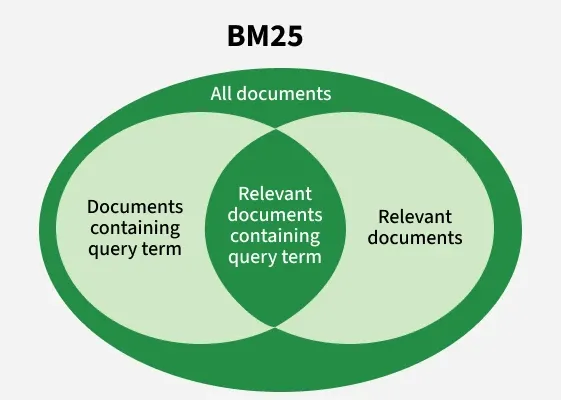

BM25 сравнивает **токены**. Запрос «почему списали комиссию» и документ «списание комиссии» пересекаются ровно по одному слову из трёх, хотя говорят об одном и том же. В русском языке с его богатой словоизменительной парадигмой это не краевой случай, а норма.

Банковская лексика особенно неудобна: *оспаривание / оспорить / оспариваемая / оспорил*, *начисление / начислять / начисленный*, *списание / списать / списанная / списали*.

Решение — **лемматизация** через `pymorphy3`. Приводим и документы, и запросы к нормальной форме, и только потом используем в BM25.

В продовом Elasticsearch ту же задачу решает морфологический анализатор: актуальные форки `nickyat/elasticsearch-analysis-morphology` (для 7.16/8.x/9.x) или официально рекомендованный путь hunspell + русские словари. Оригинальный `imotov/elasticsearch-analysis-morphology` **архивирован**, на него ориентироваться не стоит.

In [ ]:
RU_STOPWORDS = {
    "и", "в", "во", "не", "что", "он", "на", "я", "с", "со", "как", "а", "то", "все", "она",
    "так", "его", "но", "да", "ты", "к", "у", "же", "вы", "за", "бы", "по", "только", "ее",
    "мне", "было", "вот", "от", "меня", "еще", "нет", "о", "из", "ему", "теперь", "когда",
    "даже", "ну", "ли", "если", "или", "быть", "был", "него", "до", "вас", "нибудь", "уж",
    "ведь", "там", "потом", "себя", "ничего", "ей", "они", "тут", "где", "надо", "для",
    "этот", "тот", "весь", "мой", "свой", "который", "чтобы", "при", "также", "этого", "это",
}

class Lemmatizer:
    """Лемматизация с кэшем. При отсутствии pymorphy3 деградирует до простого усечения окончаний."""

    def __init__(self):
        self.morph = None
        self.cache: dict[str, str] = {}
        try:
            import pymorphy3
            self.morph = pymorphy3.MorphAnalyzer()
            self.mode = "pymorphy3"
        except Exception as exc:
            self.mode = "fallback-stemmer"
            print(f"pymorphy3 недоступен ({type(exc).__name__}), используется грубый стеммер. "
                  f"Качество лексической ноги будет ниже.")

    def _norm(self, word: str) -> str:
        if word in self.cache:
            return self.cache[word]
        if self.morph is not None:
            lemma = self.morph.parse(word)[0].normal_form
        else:
            lemma = word
            for suffix in ("ниями", "ниям", "ниях", "ния", "нию", "ние", "ями", "ами", "ого",
                           "ему", "ыми", "ими", "ой", "ая", "ые", "ий", "ов", "ам", "ах",
                           "ям", "ях", "ей", "ем", "ом", "ах", "ла", "ли", "ть", "ся",
                           "а", "я", "о", "е", "ы", "и", "у", "ю"):
                if len(lemma) > 5 and lemma.endswith(suffix):
                    lemma = lemma[: -len(suffix)]
                    break
        self.cache[word] = lemma
        return lemma

    def tokens(self, text: str) -> list[str]:
        words = re.findall(r"(?u)[а-яёa-z0-9]+(?:-[а-яёa-z0-9]+)?", text.lower())
        out = []
        for word in words:
            if word in RU_STOPWORDS or len(word) < 2:
                continue
            out.append(self._norm(word))
        return out

    def normalize(self, text: str) -> str:
        return " ".join(self.tokens(text))

lemmatizer = Lemmatizer()
print(f"Режим лемматизации: {lemmatizer.mode}\n")

TRAPS = [
    ("почему с меня списали комиссию", "порядок списания комиссии за операцию"),
    ("хочу оспорить операцию", "приём заявления на оспаривание операции"),
    ("когда начислят бонусы", "начисление бонусов производится на следующий день"),
    ("вернуть деньги за перевод", "возврат средств по неисполненному переводу"),
    ("перевод не дошёл получателю", "неисполненные переводы и их разбор"),
]
print(f"{'запрос':<38} {'документ':<48} общих лемм")
print("-" * 100)
for query, document in TRAPS:
    q_raw = set(re.findall(r"(?u)[а-яёa-z]+", query.lower())) - RU_STOPWORDS
    d_raw = set(re.findall(r"(?u)[а-яёa-z]+", document.lower())) - RU_STOPWORDS
    q_lem, d_lem = set(lemmatizer.tokens(query)), set(lemmatizer.tokens(document))
    print(f"{query[:37]:<38} {document[:47]:<48} "
          f"без лемм {len(q_raw & d_raw)} -> с леммами {len(q_lem & d_lem)}")

print("\nПример нормализации:")
for word in ["списали", "списание", "оспаривание", "оспорить", "начисленные", "комиссии"]:
    print(f"  {word:<14} -> {lemmatizer._norm(word)}")

Режим лемматизации: pymorphy3

запрос                                 документ                                         общих лемм
----------------------------------------------------------------------------------------------------
почему с меня списали комиссию         порядок списания комиссии за операцию            без лемм 0 -> с леммами 1
хочу оспорить операцию                 приём заявления на оспаривание операции          без лемм 0 -> с леммами 1
когда начислят бонусы                  начисление бонусов производится на следующий де  без лемм 0 -> с леммами 1
вернуть деньги за перевод              возврат средств по неисполненному переводу       без лемм 0 -> с леммами 1
перевод не дошёл получателю            неисполненные переводы и их разбор               без лемм 0 -> с леммами 1

Пример нормализации:
  списали        -> списать
  списание       -> списание
  оспаривание    -> оспаривание
  оспорить       -> оспорить
  начисленные    -> начислить
  комиссии       -> комиссия


**Пояснения к результату:**
- На каждой паре число общих токенов после лемматизации выросло. Именно эти попадания BM25 без лемматизации теряет полностью — не «находит хуже», а **не находит вовсе**.
- Слова «списали» и «списание» сводятся к разным леммам («списать» и «списание»), потому что это разные части речи. Полностью проблему лемматизация не решает; остаток закрывает плотная нога. Это и есть аргумент за гибрид: у каждой ноги свои слепые зоны.
- Стоп-слова убираем до лемматизации — иначе тратим анализатор на «и», «в», «что».
- Ветка `fallback-stemmer` нужна для устойчивости ноутбука, но качество у неё заметно ниже. Если она включилась — переустановите `pymorphy3`.

## Раздел 3. Contextual retrieval: спасаем чанки тарифных таблиц

Вернёмся к чанку `'комиссия 1,5 % от суммы, минимум 199 ₽'`. Ни один эмбеддер не сможет связать его с запросом «сколько стоит снять деньги в чужом банкомате с Классика», потому что в тексте чанка **нет ни банкомата, ни Классика**.

**Contextual retrieval** (Anthropic, сентябрь 2024): перед индексацией LLM дописывает к каждому чанку короткий контекст его места в документе. Заявленный авторами эффект на их корпусе: contextual embeddings снижают частоту промахов top-20 на 35 %, contextual embeddings + contextual BM25 — на 49 %, а с добавлением реранкинга — на 67 %. Это **заявления вендора на его бенчмарке**, а не независимо проверенный результат, и на GigaChat с русским корпусом они напрямую не переносятся — берём как ориентир ожидаемого порядка эффекта.

Контекстуализацию у нас выполняет GigaChat. Дальше в ноутбуке индексируем **и сырой, и контекстуализированный** варианты, чтобы увидеть разницу на своих запросах.

In [ ]:
CONTEXT_PROMPT = """Ты готовишь части тарифного сборника Сбера к индексации в поиске.
Дано: раздел документа и сырой текст части документа (ячейка таблицы).
Напиши ОДНО предложение, которое ставит чанк в контекст: о какой операции, каком продукте
и каком периоде действия речь. Используй формулировки, которыми клиент задал бы вопрос.
Не добавляй фактов, которых нет во входных данных. Верни только это предложение, без кавычек.

Раздел документа: {section}
Продукт: {product}
Период действия: с {valid_from} по {valid_to}
Тип документа: {doc_type}
Сырой текст чанка: {text}"""

def contextualize(doc: Doc) -> str:
    """Дописывает LLM-контекст перед сырым чанком. Индексируется результат целиком."""
    prompt = CONTEXT_PROMPT.format(section=doc.section, product=doc.product,
                                   valid_from=doc.valid_from, valid_to=doc.valid_to,
                                   doc_type=doc.doc_type, text=doc.text)
    try:
        ctx = llm.invoke(prompt).content.strip().replace("\n", " ")
    except Exception as exc:
        print(f"  контекстуализация {doc.doc_id} v{doc.version} не удалась: {type(exc).__name__}")
        ctx = f"{doc.section}. Период действия с {doc.valid_from} по {doc.valid_to}."
    return f"{ctx} {doc.text}"

# Контекстуализируем только тарифные таблицы: именно там сырые чанки бесполезны.
# Регламенты и инструкции — уже связный текст, им контекст не нужен (и он стоил бы токенов зря).
NEEDS_CONTEXT = [d for d in CORPUS if d.doc_type == "tariff"]
print(f"Контекстуализируем {len(NEEDS_CONTEXT)} тарифных чанков (по одному вызову GigaChat на чанк)...")

t0 = time.time()
CONTEXTUAL_TEXT: dict[tuple[str, int], str] = {}
for i, doc in enumerate(NEEDS_CONTEXT, 1):
    CONTEXTUAL_TEXT[(doc.doc_id, doc.version)] = contextualize(doc)
    if i % 8 == 0:
        print(f"  ...{i}/{len(NEEDS_CONTEXT)}")
print(f"Готово за {time.time() - t0:.0f} с\n")

def index_text(doc: Doc) -> str:
    """ПОЛЕ ДЛЯ ПЛОТНОЙ НОГИ: только смысл, без идентификаторов.
    Контекстуализированный текст там, где он есть; иначе — section + text."""
    return CONTEXTUAL_TEXT.get((doc.doc_id, doc.version), f"{doc.section}. {doc.text}")

def lexical_text(doc: Doc) -> str:
    """ПОЛЕ ДЛЯ ЛЕКСИЧЕСКОЙ НОГИ: то же плюс идентификаторы — doc_id и номер приказа.

    Это разные поля индекса, и это осознанное решение. Номер приказа в плотном векторе —
    шум: у «62-Т» нет семантики, и он только размывает эмбеддинг. Зато в BM25 это
    точный, отлично находимый токен. Классический приём: одно хранилище, разные поля
    под разные ноги поиска."""
    return f"{index_text(doc)} {doc.doc_id} {doc.order_no}"

for doc in [d for d in CORPUS if d.doc_id == "TARIFF-001"]:
    print(f"--- {doc.doc_id} v.{doc.version} ({doc.valid_from}..{doc.valid_to}) ---")
    print(f"  СЫРОЙ         : {doc.text}")
    print(f"  С КОНТЕКСТОМ  : {textwrap.fill(index_text(doc), 96, subsequent_indent='                  ')}")
    print()

Контекстуализируем 47 тарифных чанков (по одному вызову GigaChat на чанк)...
  ...8/47
  ...16/47
  ...24/47
  ...32/47
  ...40/47
Готово за 49 с

--- TARIFF-001 v.3 (2026-01-01..2026-06-30) ---
  СЫРОЙ         : комиссия 2,0 % от суммы, минимум 250 ₽; лимит без комиссии 0 ₽/мес
  С КОНТЕКСТОМ  : Какой процент комиссии и какие лимиты действуют при снятии наличных с карты Классик в банкоматах
                  других банков с 1 января по 30 июня 2026 года? комиссия 2,0 % от суммы,
                  минимум 250 ₽; лимит без комиссии 0 ₽/мес

--- TARIFF-001 v.4 (2026-07-01..2099-12-31) ---
  СЫРОЙ         : комиссия 1,5 % от суммы, минимум 199 ₽; лимит без комиссии 20 000 ₽/мес
  С КОНТЕКСТОМ  : Какой будет размер комиссии и лимиты при снятии наличных с карты Классик в банкоматах других
                  банков с 1 июля 2026 года? комиссия 1,5 % от суммы, минимум 199 ₽; лимит без
                  комиссии 20 000 ₽/мес



**Пояснения к результату:**
- Контекстуализированный чанк теперь содержит и операцию, и продукт, и период. Он стал **находимым** — и плотной ногой, и лексической.
- Контекстуализируем не всё, а только тарифные таблицы. Регламенты и инструкции — уже связный текст; дописывать им контекст значит платить за вызов LLM без выигрыша. **Contextual retrieval применяется избирательно, по типу чанка.**
- Это разовая стоимость индексации, а не стоимость запроса. Anthropic отдельно отмечает, что дешёвой её делает prompt caching (~$1.02 на 1 млн токенов документов); у GigaChat такого механизма нет, поэтому индексацию планируйте как батч-задачу.
- В `index_text` для неконтекстуализированных документов мы всё равно приклеиваем `section`. Дешёвый детерминированный приём, который стоит применять всегда — даже без LLM.
- **Обратите внимание на два разных поля индекса.** `index_text` идёт в плотную ногу и содержит только смысл. `lexical_text` идёт в BM25 и дополнительно включает `doc_id` и номер приказа. Причина: у токена «62-Т» нет семантики — в плотном векторе он лишь размывает эмбеддинг, а в инвертированном индексе это идеально точный ключ. Одно хранилище, разные поля под разные ноги — стандартный приём, и именно он делает возможным поиск по «приказ 62-Т» в следующем разделе.

## Раздел 4. Лексический поиск: BM25 на `bm25s`

`bm25s` — быстрая реализация BM25 на разреженных матрицах, разумная замена кластерному Elasticsearch в ноутбуке. В BM25 попадает уже **лемматизированный** текст из раздела 2.

Что при этом остаётся за кадром и что нужно знать про прод:
- в Elasticsearch/OpenSearch есть абстракция `retriever` с `rrf` и `linear` — слияние выполняется **на стороне поискового кластера**, одним запросом;
- `rrf` работает по рангам, `linear` — взвешенная сумма с MinMax-нормализацией; второй даёт больше контроля, но требует калибровки;
- **важный нюанс шардирования:** RRF считается по рангам внутри выдачи, поэтому при слиянии результатов с нескольких шардов порядок может отличаться от единого индекса. На малых корпусах незаметно, на больших — источник плавающих результатов.


In [ ]:
class LexicalIndex:
    """BM25 поверх лемматизированного корпуса. Основной путь — bm25s, при его отсутствии —
    компактная собственная реализация (Okapi BM25), чтобы ноутбук оставался рабочим."""

    def __init__(self, docs: list[Doc], lemmatizer: Lemmatizer, k1: float = 1.5, b: float = 0.75):
        self.docs = docs
        self.lemmatizer = lemmatizer
        self.k1, self.b = k1, b
        self.corpus_tokens = [lemmatizer.tokens(lexical_text(d)) for d in docs]
        self.backend = None
        try:
            import bm25s
            self.bm25s = bm25s
            tokenized = bm25s.tokenize([" ".join(t) for t in self.corpus_tokens],
                                       stopwords=None, stemmer=None, show_progress=False)
            self.model = bm25s.BM25(k1=k1, b=b)
            self.model.index(tokenized, show_progress=False)
            self.backend = "bm25s"
        except Exception as exc:
            print(f"bm25s недоступен ({type(exc).__name__}), включена собственная реализация BM25.")
            self._build_own()
            self.backend = "own"

    def _build_own(self):
        self.doc_freq = Counter()
        for tokens in self.corpus_tokens:
            self.doc_freq.update(set(tokens))
        self.doc_len = [len(t) for t in self.corpus_tokens]
        self.avg_len = sum(self.doc_len) / max(len(self.doc_len), 1)
        self.tf = [Counter(t) for t in self.corpus_tokens]
        self.n_docs = len(self.corpus_tokens)

    def search(self, query: str, k: int = 20) -> list[tuple[int, float]]:
        q_tokens = self.lemmatizer.tokens(query)
        if not q_tokens:
            return []
        if self.backend == "bm25s":
            q = self.bm25s.tokenize(" ".join(q_tokens), stopwords=None, stemmer=None,
                                    show_progress=False)
            k_eff = min(k, len(self.docs))
            idx, scores = self.model.retrieve(q, k=k_eff, show_progress=False)
            return [(int(idx[0][i]), float(scores[0][i])) for i in range(k_eff)
                    if float(scores[0][i]) > 0]
        # собственная реализация
        results = []
        for doc_idx in range(self.n_docs):
            score, tf, length = 0.0, self.tf[doc_idx], self.doc_len[doc_idx]
            for token in q_tokens:
                freq = tf.get(token, 0)
                if not freq:
                    continue
                idf = math.log(1 + (self.n_docs - self.doc_freq[token] + 0.5) /
                               (self.doc_freq[token] + 0.5))
                denom = freq + self.k1 * (1 - self.b + self.b * length / self.avg_len)
                score += idf * freq * (self.k1 + 1) / denom
            if score > 0:
                results.append((doc_idx, score))
        results.sort(key=lambda x: -x[1])
        return results[:k]

lexical = LexicalIndex(CORPUS, lemmatizer)
print(f"Лексический индекс собран, backend = {lexical.backend}, документов = {len(CORPUS)}\n")

for query in ["почему списали 250 рублей за снятие в чужом банкомате",
              "приказ 62-Т",
              "сколько рассматривается заявление по карте международной платёжной системы"]:
    print(f"ЗАПРОС: {query}")
    for rank, (doc_idx, score) in enumerate(lexical.search(query, k=3), 1):
        doc = CORPUS[doc_idx]
        print(f"  {rank}. score={score:6.2f}  {doc.doc_id} v.{doc.version:<2} {doc.section[:52]}")
    print()

DEBUG:bm25s:Building index from IDs objects


Лексический индекс собран, backend = bm25s, документов = 104

ЗАПРОС: почему списали 250 рублей за снятие в чужом банкомате
  1. score=  2.93  TARIFF-001 v.3  Снятие наличных в банкоматах сторонних банков × Клас
  2. score=  2.12  TARIFF-REG-001 v.1  Региональная надбавка × Новосибирская область
  3. score=  2.12  TARIFF-REG-002 v.1  Региональная надбавка × Республика Татарстан

ЗАПРОС: приказ 62-Т
  1. score=  1.31  TARIFF-008 v.4  SMS-информирование × Классик
  2. score=  1.31  TARIFF-011 v.4  Конвертация при операции в валюте × Классик
  3. score=  1.29  TARIFF-009 v.4  Выпуск дополнительной карты × Классик

ЗАПРОС: сколько рассматривается заявление по карте международной платёжной системы
  1. score=  4.63  DISPUTE-RULES-008 v.1  Сроки рассмотрения оспариваемой операции
  2. score=  2.53  APP-GUIDE-031 v.1  Возврат средств при отмене покупки
  3. score=  1.82  DBO-TERMS-008 v.4  Спорные ситуации



**Пояснения к результату:**
- Запрос «приказ 62-Т» — показательный. Это **точный идентификатор**, и BM25 находит его безошибочно. Плотная нога на таких запросах регулярно промахивается: у номера приказа нет семантики.
- В выдаче про снятие наличных соседствуют версии 3 и 4 одного документа. BM25 не знает про даты — **фильтрация по времени это отдельная ступень**, к ней придём в разделе 6.
- `k1=1.5, b=0.75` — стандартные значения. `b` управляет нормализацией по длине документа: для корпуса из коротких табличных чанков и длинных регламентов её роль заметна, и это один из параметров, которые имеет смысл подбирать под свой корпус.

## Раздел 5. Семантический поиск: `GigaChatEmbeddings` в Qdrant `:memory:`

Выбор эмбеддера под русский язык определяется через бенчмарк. Основным бенчмарком здесь может быть **ruMTEB**. **GigaEmbeddings** (arXiv:2510.22369, октябрь 2025) набирает **69.1 на ruMTEB** по 23 задачам; модель построена на GigaChat-3B со стратегическим прунингом 25 % слоёв трансформера.

Альтернативы, которые стоит держать в голове: **BGE-M3** (dense + sparse + multivector в одной модели, 100+ языков, до 8192 токенов), **multilingual-e5-large**, **Qwen3-Embedding**. Их плюс — self-host без внешних вызовов, что для банка часто обязательное требование.

Складываем векторы в **Qdrant** в режиме `:memory:`. Ключевые параметры, которые надо понимать:
- **HNSW**: `m` — число связей на узел (память ↔ качество), `ef_construct` — ширина поиска при построении, `ef_search` — при запросе (латентность ↔ полнота);
- **IVF** (в других движках): `nprobe` — сколько кластеров просматривать;
- **payload-индексы** — обязательны для быстрой фильтрации по метаданным на больших коллекциях.

In [ ]:
from qdrant_client import QdrantClient, models
import zlib

COLLECTION = "meridian_docs"
qdrant = QdrantClient(location=":memory:")

def embed_batch(texts: list[str], batch_size: int = 24) -> list[list[float]]:
    """Батчевое получение эмбеддингов с устойчивостью к обрыву: у GigaChat есть лимиты на батч."""
    vectors: list[list[float]] = []
    for start in range(0, len(texts), batch_size):
        chunk = texts[start:start + batch_size]
        for attempt in range(3):
            try:
                vectors.extend(embeddings.embed_documents(chunk))
                break
            except Exception as exc:
                if attempt == 2:
                    raise
                print(f"  батч {start} упал ({type(exc).__name__}), повтор {attempt + 1}/2")
                time.sleep(2 * (attempt + 1))
        print(f"  эмбеддингов готово: {len(vectors)}/{len(texts)}", end="\r")
    print()
    return vectors

def sparse_of(tokens: list[str]) -> models.SparseVector:
    """Разреженный вектор для нативного гибрида Qdrant.
    ВАЖНО: hash() в Python рандомизирован между процессами, поэтому id термов
    строим на crc32 — детерминированно и воспроизводимо между запусками."""
    counts = Counter(tokens)
    return models.SparseVector(
        indices=[zlib.crc32(t.encode("utf-8")) % (2 ** 31) for t in counts],
        values=[float(c) for c in counts.values()],
    )

qdrant.create_collection(
    collection_name=COLLECTION,
    vectors_config={"dense": models.VectorParams(
        size=EMBED_DIM, distance=models.Distance.COSINE,
        hnsw_config=models.HnswConfigDiff(m=16, ef_construct=100),
    )},
    # modifier=IDF -> Qdrant сам применит IDF-взвешивание к term frequency
    sparse_vectors_config={"lex": models.SparseVectorParams(modifier=models.Modifier.IDF)},
)

# Payload-индексы: без них фильтр по метаданным на большой коллекции превращается в полный скан.
for field, schema in [("product", models.PayloadSchemaType.KEYWORD),
                      ("doc_type", models.PayloadSchemaType.KEYWORD),
                      ("region", models.PayloadSchemaType.KEYWORD),
                      ("doc_id", models.PayloadSchemaType.KEYWORD),
                      ("valid_from_ord", models.PayloadSchemaType.INTEGER),
                      ("valid_to_ord", models.PayloadSchemaType.INTEGER)]:
    qdrant.create_payload_index(collection_name=COLLECTION, field_name=field, field_schema=schema)

print(f"Считаем эмбеддинги для {len(CORPUS)} документов...")
index_texts = [index_text(d) for d in CORPUS]
dense_vectors = embed_batch(index_texts)

qdrant.upsert(
    collection_name=COLLECTION,
    points=[
        models.PointStruct(
            id=i,
            vector={"dense": dense_vectors[i], "lex": sparse_of(lexical.corpus_tokens[i])},
            payload={
                "doc_id": d.doc_id, "version": d.version, "doc_type": d.doc_type,
                "product": d.product, "region": d.region, "section": d.section,
                "text": d.text, "index_text": index_texts[i],
                "valid_from": d.valid_from, "valid_to": d.valid_to,
                "valid_from_ord": d.valid_from_ord, "valid_to_ord": d.valid_to_ord,
                "order_no": d.order_no,
            },
        )
        for i, d in enumerate(CORPUS)
    ],
)
print(f"В Qdrant загружено точек: {qdrant.count(COLLECTION).count}")

def dense_search(query: str, k: int = 20, flt: Optional[models.Filter] = None) -> list[tuple[int, float]]:
    qvec = embeddings.embed_query(query)
    hits = qdrant.query_points(collection_name=COLLECTION, query=qvec, using="dense",
                               limit=k, query_filter=flt,
                               search_params=models.SearchParams(hnsw_ef=128)).points
    return [(int(h.id), float(h.score)) for h in hits]

print()
for query in ["хочу вернуть деньги, которые у меня забрали при снятии",
              "приказ 62-Т"]:
    print(f"ЗАПРОС: {query}")
    for rank, (doc_idx, score) in enumerate(dense_search(query, k=3), 1):
        doc = CORPUS[doc_idx]
        print(f"  {rank}. cos={score:.3f}  {doc.doc_id} v.{doc.version:<2} {doc.section[:52]}")
    print()

Считаем эмбеддинги для 104 документов...
  эмбеддингов готово: 104/104
В Qdrant загружено точек: 104

ЗАПРОС: хочу вернуть деньги, которые у меня забрали при снятии


/tmp/ipykernel_688/1677480417.py:80: UserWarning: Local mode performs exact (brute-force) search, so `search_params` has no effect, with the exception of `idf`.
  hits = qdrant.query_points(collection_name=COLLECTION, query=qvec, using="dense",


  1. cos=0.832  APP-GUIDE-031 v.1  Возврат средств при отмене покупки
  2. cos=0.821  LOYALTY-050 v.3  Начисление бонусов программы лояльности
  3. cos=0.814  APP-GUIDE-026 v.1  Что делать при подозрении на мошенничество

ЗАПРОС: приказ 62-Т
  1. cos=0.787  APP-GUIDE-009 v.1  Блокировка карты через приложение
  2. cos=0.776  TARIFF-012 v.4  Запрос выписки за период свыше 12 месяцев × ДБО
  3. cos=0.776  APP-GUIDE-003 v.1  Где посмотреть выписку



**Пояснения к результату:**
- «Вернуть деньги, которые забрали» — в корпусе таких слов нет, но плотная нога находит документы про комиссию и оспаривание. Это ровно то, чего BM25 не умеет.
- «Приказ 62-Т» — сравните с BM25 из раздела 4. Косинус тут даёт размытую выдачу: у идентификатора нет семантики, и в векторном пространстве он ни к чему не близок. **Это не недостаток модели, это свойство задачи.**
- Два запроса, две противоположные картины — исчерпывающее обоснование гибрида. Не «вектор лучше BM25» и не наоборот; у них разные слепые зоны.
- `hnsw_ef=128` при запросе — та самая ручка «латентность против полноты». Уменьшите до 32 и посмотрите, изменится ли выдача.

## Раздел 6. RRF: слияние выдач и темпоральный фильтр

**Reciprocal Rank Fusion:**

$$\text{RRF}(d) = \sum_{r \in \text{runs}} \frac{1}{k + \text{rank}_r(d)}$$

где `rank` — позиция документа в выдаче (с 1), а `k` — сглаживающая константа (обычно 60). Смысл `k`: чем он больше, тем меньше разница между первым и десятым местом, то есть тем «мягче» слияние.

Ключевое свойство: **на входе только ранги**. Значения BM25 (12.7) и косинуса (0.83) несопоставимы, но их позиции — вполне. Поэтому RRF не требует нормализации и работает «из коробки» на любых парах ретриверов.

Сразу добавляем **темпоральный фильтр** — то, ради чего строился весь кейс. Условие «документ действовал на дату операции»:

```
valid_from_ord <= дата_операции <= valid_to_ord
```

Реализуем сначала прозрачно (свой RRF поверх двух выдач), затем — нативно на стороне Qdrant через Query API с `prefetch` и `FusionQuery`.

In [ ]:
RRF_K = 60

def rrf_fuse(runs: list[list[tuple[int, float]]], k: int = RRF_K,
             weights: Optional[list[float]] = None) -> list[tuple[int, float]]:
    """Слияние нескольких выдач по обратным рангам. weights позволяет доверять одной ноге больше."""
    weights = weights or [1.0] * len(runs)
    fused: dict[int, float] = defaultdict(float)
    for run, weight in zip(runs, weights):
        for rank, (doc_idx, _score) in enumerate(run, start=1):
            fused[doc_idx] += weight / (k + rank)
    return sorted(fused.items(), key=lambda x: -x[1])

def temporal_filter(operation_date: Optional[str] = None, product: Optional[str] = None,
                    region: Optional[str] = None, doc_type: Optional[str] = None) -> Optional[models.Filter]:
    """Фильтр по метаданным: документ действовал на дату операции + продуктовый/региональный отбор."""
    must: list[Any] = []
    if operation_date:
        ordinal = date.fromisoformat(operation_date).toordinal()
        must.append(models.FieldCondition(key="valid_from_ord", range=models.Range(lte=ordinal)))
        must.append(models.FieldCondition(key="valid_to_ord", range=models.Range(gte=ordinal)))
    if product:
        # продукт клиента ИЛИ общие для ДБО документы
        must.append(models.Filter(should=[
            models.FieldCondition(key="product", match=models.MatchValue(value=product)),
            models.FieldCondition(key="product", match=models.MatchValue(value="ДБО")),
        ]))
    if region:
        must.append(models.Filter(should=[
            models.FieldCondition(key="region", match=models.MatchValue(value=region)),
            models.FieldCondition(key="region", match=models.MatchValue(value="все")),
        ]))
    if doc_type:
        must.append(models.FieldCondition(key="doc_type", match=models.MatchValue(value=doc_type)))
    return models.Filter(must=must) if must else None

def allowed_ids(flt: Optional[models.Filter]) -> Optional[set[int]]:
    """Какие точки проходят фильтр — нужно, чтобы применить его и к лексической ноге,
    которая живёт вне Qdrant. В продовом ES обе ноги фильтруются одним запросом."""
    if flt is None:
        return None
    ids, offset = set(), None
    while True:
        points, offset = qdrant.scroll(collection_name=COLLECTION, scroll_filter=flt,
                                       limit=256, offset=offset, with_payload=False)
        ids.update(int(p.id) for p in points)
        if offset is None:
            break
    return ids

def hybrid_search(query: str, k: int = 10, candidates: int = 30,
                  operation_date: Optional[str] = None, product: Optional[str] = None,
                  region: Optional[str] = None, weights: Optional[list[float]] = None) -> dict:
    """Гибридный поиск: BM25 + dense -> RRF, с фильтром по метаданным. Возвращает выдачу и тайминги."""
    flt = temporal_filter(operation_date, product, region)
    keep = allowed_ids(flt)

    t0 = time.perf_counter()
    lex_run = [(i, s) for i, s in lexical.search(query, k=candidates * 2)
               if keep is None or i in keep][:candidates]
    t_lex = time.perf_counter() - t0

    t0 = time.perf_counter()
    dense_run = dense_search(query, k=candidates, flt=flt)
    t_dense = time.perf_counter() - t0

    t0 = time.perf_counter()
    fused = rrf_fuse([lex_run, dense_run], weights=weights)[:k]
    t_fuse = time.perf_counter() - t0

    return {
        "fused": fused, "lexical": lex_run, "dense": dense_run,
        "filtered_pool": len(keep) if keep is not None else len(CORPUS),
        "timings_ms": {"lexical": t_lex * 1000, "dense": t_dense * 1000, "fusion": t_fuse * 1000},
    }

def show(result_run: list[tuple[int, float]], limit: int = 4, title: str = ""):
    if title:
        print(f"  {title}")
    for rank, (doc_idx, score) in enumerate(result_run[:limit], 1):
        doc = CORPUS[doc_idx]
        print(f"    {rank}. {score:7.4f}  {doc.doc_id} v.{doc.version:<2} "
              f"({doc.valid_from}..{doc.valid_to}) {doc.section[:44]}")


print("=" * 100)
print("ОДИН И ТОТ ЖЕ ВОПРОС, ДВЕ РАЗНЫЕ ДАТЫ ОПЕРАЦИИ")
print("=" * 100)
for label, op_date in [("операция 2026-06-14 (действовала v.3)", "2026-06-14"),
                       ("операция 2026-08-01 (действует v.4)", "2026-08-01")]:
    QUESTION = "почему за снятие наличных в чужом банкомате удержали 250 рублей, а не 199"
    result = hybrid_search(QUESTION, k=4, operation_date=op_date, product="Классик")
    print(f"\n--- {label} | пул после фильтра: {result['filtered_pool']} из {len(CORPUS)} док. ---")
    show(result["fused"], 4, "RRF:")
    print(f"  тайминги, мс: {', '.join(f'{k}={v:.1f}' for k, v in result['timings_ms'].items())}")

print("\n" + "=" * 100)
print("БЕЗ ТЕМПОРАЛЬНОГО ФИЛЬТРА — в выдаче обе редакции, модель выберет наугад")
print("=" * 100)
QUESTION = "почему за снятие наличных в чужом банкомате удержали 250 рублей, а не 199"
no_filter = hybrid_search(QUESTION, k=4, product="Классик")
show(no_filter["fused"], 4, "RRF без фильтра по дате:")

**Пояснения к результату:**
- Главный результат занятия: **один вопрос, две даты, две разные корректные редакции тарифа**. Пул документов после фильтра сжимается, и в выдаче остаётся только то, что действовало.
- Последний блок показывает цену отказа от фильтра: обе редакции в выдаче одновременно. Дальше модель выберет ту, что выше по рангу, — то есть **фактическая корректность ответа станет делом случая**. Никакой промпт это не лечит.
- Обратите внимание на тайминги: лексическая нога на порядок быстрее плотной, потому что плотная делает сетевой вызов за эмбеддингом запроса. В проде это первое место, куда ставят кэш эмбеддингов частых запросов.
- Фильтр к лексической ноге мы применяем **вручную** через `allowed_ids`, потому что BM25 живёт вне Qdrant. В Elasticsearch с `retriever`-API обе ноги фильтруются одним запросом — это аргумент в пользу единого движка, когда он уже есть в контуре.

### Нативное слияние на стороне Qdrant: Query API с `prefetch` и `Fusion.RRF`

Свой RRF полезен для понимания, но в проде слияние лучше отдать хранилищу: меньше сетевых round-trip, меньше кода. Qdrant умеет это через `prefetch` + `FusionQuery`.

Доступны два режима:
- `Fusion.RRF` — по рангам, как мы считали руками;
- `Fusion.DBSF` — Distribution-Based Score Fusion, по нормализованным значениям score; чувствительнее к распределению, иногда точнее на однородных корпусах.

In [ ]:
QUESTION = "почему за снятие наличных в чужом банкомате удержали 250 рублей, а не 199"

def qdrant_native_hybrid(query: str, k: int = 5, candidates: int = 30,
                         operation_date: Optional[str] = None, product: Optional[str] = None,
                         fusion: models.Fusion = models.Fusion.RRF) -> list[tuple[int, float]]:
    """Слияние выполняет сам Qdrant: две prefetch-ветки (dense + sparse) и FusionQuery."""
    flt = temporal_filter(operation_date, product)
    qvec = embeddings.embed_query(query)
    qsparse = sparse_of(lemmatizer.tokens(query))
    hits = qdrant.query_points(
        collection_name=COLLECTION,
        prefetch=[
            models.Prefetch(query=qvec, using="dense", limit=candidates, filter=flt),
            models.Prefetch(query=qsparse, using="lex", limit=candidates, filter=flt),
        ],
        query=models.FusionQuery(fusion=fusion),
        limit=k,
        query_filter=flt,
    ).points
    return [(int(h.id), float(h.score)) for h in hits]

try:
    for fusion_mode, name in [(models.Fusion.RRF, "Fusion.RRF"), (models.Fusion.DBSF, "Fusion.DBSF")]:
        native = qdrant_native_hybrid(QUESTION, k=4, operation_date="2026-06-14",
                                      product="Классик", fusion=fusion_mode)
        print(f"--- Qdrant {name} ---")
        show(native, 4)
        print()
except Exception as exc:
    print(f"Нативное слияние недоступно в этой версии qdrant-client ({type(exc).__name__}: {exc}).")
    print("Собственный rrf_fuse из предыдущей ячейки остаётся рабочим путём.")

Нативное слияние недоступно в этой версии qdrant-client (NameError: name 'QUESTION' is not defined).
Собственный rrf_fuse из предыдущей ячейки остаётся рабочим путём.


**Пояснения к результату:**
- Порядок близок к нашему ручному RRF, но не обязан совпадать: разреженный вектор Qdrant строится по crc32-идентификаторам термов с IDF-модификатором, а `bm25s` считает полноценный Okapi BM25 с нормализацией по длине документа. Это **две разные лексические ноги**, и разница в выдаче — ожидаемая.
- `Fusion.DBSF` работает с нормализованными значениями, а не рангами, поэтому сильнее реагирует на «уверенную» одиночную ногу. Что лучше — решается на своём корпусе, а не по документации.
- **Про шардирование:** RRF считается по рангам внутри выдачи. Если коллекция разбита на шарды, ранги локальны для шарда, и результат единого индекса может отличаться. Держите это в голове, когда выдача «плавает» после масштабирования.

## Раздел 7. Реранкер: cross-encoder как последняя ступень

BM25 и плотный поиск — **bi-encoder** по природе: запрос и документ кодируются независимо, поэтому поиск быстрый, но взаимодействие между ними огрублённое. **Cross-encoder** подаёт пару (запрос, документ) в модель вместе и выдаёт значение релевантности. Точнее, но дороже — поэтому его пускают только на top-k кандидатов после слияния.

Выбор модели для банка обычно диктуется не только качеством:
- **BGE-reranker-v2-m3** — Apache-2.0, мультиязычный, self-host. Дефолт для контура, где внешний rerank-API недопустим;
- Cohere Rerank, Voyage rerank-2.5 — сильнее, но это внешний API;
- ColBERT / ColPali (late-interaction) — опция «если cross-encoder не хватает»: токенные эмбеддинги и MaxSim, применяются к 100–500 кандидатам.

In [ ]:
RERANKER_MODEL = os.environ.get("RERANKER_MODEL", "BAAI/bge-reranker-v2-m3")
# Более компактные варианты, если Colab без GPU или мало места:
#   "BAAI/bge-reranker-base"
#   "cross-encoder/mmarco-mMiniLMv2-L12-H384-v1"

reranker = None
try:
    from sentence_transformers import CrossEncoder
    t0 = time.time()
    reranker = CrossEncoder(RERANKER_MODEL, max_length=512)
    print(f"Реранкер {RERANKER_MODEL} загружен за {time.time() - t0:.0f} с")
except Exception as exc:
    print(f"Реранкер недоступен ({type(exc).__name__}: {exc}).")
    print("Ступень реранкинга будет пропущена; конвейер остаётся рабочим на RRF.")

def rerank(query: str, run: list[tuple[int, float]], top_k: int = 5) -> tuple[list[tuple[int, float]], float]:
    """Переупорядочивает кандидатов cross-encoder'ом. Возвращает выдачу и латентность в мс."""
    if reranker is None or not run:
        return run[:top_k], 0.0
    pairs = [(query, index_text(CORPUS[doc_idx])) for doc_idx, _ in run]
    t0 = time.perf_counter()
    scores = reranker.predict(pairs, show_progress_bar=False)
    latency = (time.perf_counter() - t0) * 1000
    ranked = sorted(zip([i for i, _ in run], [float(s) for s in scores]), key=lambda x: -x[1])
    return ranked[:top_k], latency

probe_query = "как долго ждать решение по спорной операции по карте Visa"
res = hybrid_search(probe_query, k=10, candidates=30, product="Классик")
print(f"\nЗАПРОС: {probe_query}\n")
show(res["fused"], 5, "ДО реранкинга (RRF):")
reranked, rerank_ms = rerank(probe_query, res["fused"], top_k=5)
print()
show(reranked, 5, f"ПОСЛЕ реранкинга (cross-encoder, {rerank_ms:.0f} мс):")

print("\nЛатентность ступеней конвейера, мс:")
stages = dict(res["timings_ms"]); stages["rerank"] = rerank_ms
for stage, value in stages.items():
    bar = "#" * max(int(value / 5), 1)
    print(f"  {stage:<9} {value:7.1f}  {bar}")
print(f"  {'ИТОГО':<9} {sum(stages.values()):7.1f}")

**Пояснения к результату:**
- Реранкер меняет порядок, а не состав: он работает по кандидатам, которые дало слияние. **Если нужный документ не попал в top-30 после RRF, реранкер его не спасёт.** Отсюда практическое правило: сначала добиваемся полноты на первой ступени, потом улучшаем порядок.
- Обратите внимание на шкалы: значения cross-encoder не сопоставимы со значениями RRF. Смешивать их в одной формуле без нормализации нельзя.
- Латентность — часть контракта продукта. Cross-encoder на CPU в Colab легко становится доминирующей ступенью; в этом случае либо GPU, либо меньше кандидатов, либо более компактная модель.
- Мы смотрим на **дельты и латентность как на инженерную интуицию**. Систематическая оценка (какая ступень сколько даёт, стоит ли она денег) требует датасета и judges — это занятия 9–12.

## Раздел 8. Хранилища под роли памяти: in-memory, Redis с TTL, векторная БД

Типичная ошибка проектирования — сложить всё в одно хранилище. Роли памяти имеют **разные требования по времени жизни, скорости и способу доступа**, и правильный маппинг выглядит так:

| Роль памяти | Хранилище | Доступ | Время жизни |
|---|---|---|---|
| рабочая память шага (промежуточные результаты инструментов) | in-memory / state графа | по ключу | до конца хода |
| сессия обращения (окно диалога, черновик заявления) | **Redis с TTL** | по ключу | часы–дни, авто-истечение |
| семантика документов и памяти о клиенте | **векторная БД** | по вектору + фильтр | месяцы–годы |

`fakeredis` даёт полноценный интерфейс Redis без внешнего сервиса. В проде это Redis 8+ (RedisJSON/RediSearch уже включены) либо `langgraph-checkpoint-redis` с `RedisSaver` / `RedisStore`, где TTL настраивается через `ttl={"default_ttl": ..., "refresh_on_read": True}`.

Ключевой параметр — `refresh_on_read`: продлевать ли жизнь записи при чтении. Для активного обращения — да, для аудита — категорически нет.

In [ ]:
SESSION_TTL_SECONDS = 3600 * 6   # обращение живёт 6 часов бездействия

try:
    import fakeredis
    redis_client = fakeredis.FakeStrictRedis(decode_responses=True)
    redis_backend = "fakeredis"
except Exception as exc:
    redis_client, redis_backend = None, f"НЕТ ({type(exc).__name__})"

class SessionStore:
    """Роль: сессия обращения. Redis + TTL, с опцией refresh_on_read."""

    def __init__(self, client, ttl: int = SESSION_TTL_SECONDS, refresh_on_read: bool = True):
        self.client, self.ttl, self.refresh_on_read = client, ttl, refresh_on_read
        self.fallback: dict[str, str] = {}

    def _key(self, case_id: str) -> str:
        return f"meridian:session:{case_id}"

    def save(self, case_id: str, payload: dict):
        blob = json.dumps(payload, ensure_ascii=False)
        if self.client:
            self.client.setex(self._key(case_id), self.ttl, blob)
        else:
            self.fallback[self._key(case_id)] = blob

    def load(self, case_id: str) -> Optional[dict]:
        key = self._key(case_id)
        if self.client:
            blob = self.client.get(key)
            if blob and self.refresh_on_read:
                self.client.expire(key, self.ttl)   # продлеваем жизнь активного обращения
        else:
            blob = self.fallback.get(key)
        return json.loads(blob) if blob else None

    def ttl_left(self, case_id: str) -> int:
        return self.client.ttl(self._key(case_id)) if self.client else -1

class WorkingMemory:
    """Роль: рабочая память шага. Живёт в процессе, кэширует результаты ретривера в пределах хода."""

    def __init__(self):
        self.slots: dict[str, Any] = {}
        self.retrieval_cache: dict[tuple, Any] = {}
        self.hits = 0
        self.misses = 0

    def cached_search(self, query: str, **kwargs):
        key = (query, tuple(sorted(kwargs.items())))
        if key in self.retrieval_cache:
            self.hits += 1
            return self.retrieval_cache[key]
        self.misses += 1
        value = hybrid_search(query, **kwargs)
        self.retrieval_cache[key] = value
        return value

sessions = SessionStore(redis_client)
working = WorkingMemory()

CASE_ID = "case-2026-08-13-0091"
sessions.save(CASE_ID, {
    "client_id": "client-4471", "product": "Классик",
    "operation_date": "2026-06-14", "amount": 12500.0, "currency": "RUB",
    "channel": "банкомат", "region": "Новосибирская область",
    "draft_status": "собираем реквизиты",
})
print(f"Redis backend: {redis_backend}")
print(f"Сессия сохранена, TTL осталось: {sessions.ttl_left(CASE_ID)} с")
print("Прочитано из сессии:", json.dumps(sessions.load(CASE_ID), ensure_ascii=False, indent=2))

# Демонстрация рабочей памяти: повторный запрос в пределах хода не идёт в ретривер
for _ in range(3):
    working.cached_search(QUESTION, k=5, operation_date="2026-06-14", product="Классик")
print(f"\nКэш ретривера в рабочей памяти: попаданий {working.hits}, промахов {working.misses}")
print("Каждое попадание — это сэкономленный вызов эмбеддингов и обход индекса.")

print("\nМаппинг роль -> хранилище в нашем агенте:")
print(f"  рабочая память шага : WorkingMemory (in-process), записей в кэше {len(working.retrieval_cache)}")
print(f"  сессия обращения    : {redis_backend}, TTL {SESSION_TTL_SECONDS} с, refresh_on_read=True")
print(f"  семантика документов: Qdrant :memory:, точек {qdrant.count(COLLECTION).count}, "
      f"HNSW m=16 ef_construct=100")

**Пояснения к результату:**
- TTL — это не «удаление по расписанию», а **встроенная политика забывания**. Сессия, к которой никто не вернулся за 6 часов, исчезает сама, без задачи-уборщика. Для сессионных данных это сильно надёжнее ручной очистки.
- `refresh_on_read=True` продлевает жизнь активного обращения. Ровно этого **нельзя** делать с аудитом и с данными, у которых есть регуляторный срок хранения: там чтение не должно продлевать жизнь записи. Разграничение политик по ролям — тема занятия 8.
- Кэш в рабочей памяти окупается сразу: в одном ходу агент часто переспрашивает ретривер похожим запросом, а каждый промах — это сетевой вызов за эмбеддингом.

## Практика

Собираем всё в один конвейер, оформляем его как LangChain `@tool` и вставляем в граф LangGraph. Retrieval становится **агентным**: модель сама решает, искать ли и с какими параметрами, а не вызывается фиксированной цепочкой.

Затем прогоняем набор из 20 запросов с морфологическими ловушками и сравниваем четыре конфигурации: BM25 / dense / RRF / RRF + реранкер.

**Ещё раз про измерения:** мы смотрим, попал ли целевой документ в top-5, как **инженерную интуицию** — «эта ступень помогает или нет». Это не метрика приёмки. Датасеты, judges и словарь метрик — занятия 9–12.

In [ ]:
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage

PIPELINE_LOG: list[dict] = []

def full_pipeline(query: str, operation_date: Optional[str] = None, product: Optional[str] = None,
                  region: Optional[str] = None, top_k: int = 4, candidates: int = 30) -> list[dict]:
    """Полный конвейер: фильтр -> BM25 + dense -> RRF -> cross-encoder. С логированием ступеней."""
    res = hybrid_search(query, k=candidates, candidates=candidates,
                        operation_date=operation_date, product=product, region=region)
    reranked, rerank_ms = rerank(query, res["fused"], top_k=top_k)
    PIPELINE_LOG.append({
        "query": query, "operation_date": operation_date, "product": product,
        "pool": res["filtered_pool"], "lex": len(res["lexical"]), "dense": len(res["dense"]),
        **{f"ms_{k}": round(v, 1) for k, v in res["timings_ms"].items()},
        "ms_rerank": round(rerank_ms, 1),
        "top": [f"{CORPUS[i].doc_id} v.{CORPUS[i].version}" for i, _ in reranked[:3]],
    })
    out = []
    for doc_idx, score in reranked:
        doc = CORPUS[doc_idx]
        out.append({"doc_id": doc.doc_id, "version": doc.version, "citation": doc.citation(),
                    "section": doc.section, "text": doc.text, "product": doc.product,
                    "valid_from": doc.valid_from, "valid_to": doc.valid_to,
                    "order_no": doc.order_no, "score": round(float(score), 4)})
    return out

@tool
def search_bank_docs(query: str, operation_date: str = "", product: str = "") -> str:
    """Поиск по документам Сбера: тарифы, регламенты, условия ДБО, инструкции.

    Args:
        query: суть вопроса своими словами, на русском.
        operation_date: дата операции клиента в формате YYYY-MM-DD. КРИТИЧНО ВАЖНО:
            указывай её всегда, если она известна, иначе поиск вернёт неверную редакцию тарифа.
        product: продукт клиента — Классик, Премиум, Вклад, СБП или ДБО.
    """
    docs = full_pipeline(query, operation_date=operation_date or None,
                         product=product or None, top_k=4)
    if not docs:
        return "По запросу ничего не найдено. Требуется эскалация на оператора."
    return "\n\n".join(f"{d['citation']}\nРаздел: {d['section']}\n{d['text']}" for d in docs)

SYSTEM_PROMPT = """Ты — ассистент клиентской поддержки Сбера.
Ты объясняешь тарифы и условия, помогаешь с картами и переводами, принимаешь заявления
на оспаривание операций и эскалируешь на оператора. Ты НЕ переводишь и не возвращаешь деньги.

ОБЯЗАТЕЛЬНЫЕ ПРАВИЛА:
1. Перед любым утверждением о тарифе, сроке или лимите вызови search_bank_docs.
2. Если известна дата операции — ВСЕГДА передавай её в operation_date. Тариф зависит от даты:
   редакция, действующая сегодня, могла не действовать в момент операции клиента.
3. Каждое утверждение подкрепляй ссылкой в формате [ID v.N действ. ...] из найденного.
4. Если подтверждающего документа нет — скажи, что уточнишь у оператора, и не выдумывай.

Отвечай кратко, на русском."""

# --- Граф LangGraph с агентным retrieval -------------------------------------
try:
    from langchain.agents import create_agent
    from langgraph.checkpoint.memory import InMemorySaver

    agent = create_agent(model=llm, tools=[search_bank_docs],
                         system_prompt=SYSTEM_PROMPT, checkpointer=InMemorySaver())

    for label, question in [
        ("июньская операция", "14 июня 2026 я снял 12500 рублей в чужом банкомате по карте Классик, "
                              "удержали 250 рублей комиссии. Почему не 199, как написано на сайте?"),
        ("августовская операция", "А если я сниму такую же сумму сегодня, 13 августа 2026, "
                                  "по карте Классик — сколько будет комиссия?"),
    ]:
        print("=" * 100)
        print(f"ВОПРОС ({label}): {question}")
        print("=" * 100)
        out = agent.invoke({"messages": [HumanMessage(question)]},
                           config={"configurable": {"thread_id": f"pract-{label}"}})
        for msg in out["messages"]:
            if isinstance(msg, AIMessage) and getattr(msg, "tool_calls", None):
                for call in msg.tool_calls:
                    print(f"  [TOOL CALL] {call['name']}({json.dumps(call['args'], ensure_ascii=False)})")
        print(f"\nОТВЕТ:\n{textwrap.fill(out['messages'][-1].content, 100)}\n")
except Exception as exc:
    print(f"create_agent недоступен ({type(exc).__name__}: {exc}); вызываем конвейер напрямую.\n")
    for op_date in ["2026-06-14", "2026-08-13"]:
        print(f"--- дата операции {op_date} ---")
        print(search_bank_docs.invoke({"query": "комиссия за снятие наличных в чужом банкомате",
                                       "operation_date": op_date, "product": "Классик"})[:600])
        print()

**Пояснения к результату:**
- Посмотрите на строки `[TOOL CALL]`: модель сама подставила `operation_date` из текста вопроса. Именно это делает retrieval агентным — параметры фильтра выводятся из диалога, а не задаются жёстко в цепочке.
- Два вопроса про «ту же самую» комиссию дают два разных ответа с разными версиями документа. И оба верны.
- Описание инструмента (docstring) — это **часть промпта**. Фраза «КРИТИЧНО ВАЖНО: указывай дату всегда» стоит там не для людей: без неё модель регулярно опускает `operation_date` и получает свежую редакцию тарифа для старой операции.

In [ ]:
# --- Набор запросов с морфологическими ловушками и сравнение четырёх конфигураций ---
# ВНИМАНИЕ: «попал ли целевой документ в top-5» здесь — инженерная интуиция, а НЕ метрика приёмки.
# Датасеты, judges и словарь метрик оценки вводятся на занятиях 9-12.

PROBE_QUERIES = [
    ("почему списали комиссию за снятие", "TARIFF-001"),
    ("списание денег в банкомате другого банка", "TARIFF-001"),
    ("сколько стоит снять наличные в чужом банкомате", "TARIFF-001"),
    ("хочу оспорить операцию", "DISPUTE-RULES-007"),
    ("оспаривание списанной суммы, какие нужны сведения", "DISPUTE-RULES-007"),
    ("как оспорил бы я неправильную комиссию", "DISPUTE-RULES-007"),
    ("сколько рассматривают заявление", "DISPUTE-RULES-008"),
    ("срок рассмотрения по карте международной платёжной системы", "DISPUTE-RULES-008"),
    ("отказали по заявлению, что делать дальше", "DISPUTE-RULES-009"),
    ("когда начисляют бонусы", "LOYALTY-050"),
    ("начисленные бонусы сколько действуют", "LOYALTY-050"),
    ("вернуть деньги за перевод который не дошёл", "APP-GUIDE-017"),
    ("перевод по СБП не зачислили получателю", "SBP-LIMITS-013"),
    ("лимит переводов через систему быстрых платежей", "SBP-LIMITS-013"),
    ("сроки перевода за границу в валюте", "SWIFT-TERMS-021"),
    ("когда переводы внутри банка не работают", "INTRA-TERMS-030"),
    ("потерял карту, сколько ждать перевыпуск", "CARD-BLOCK-041"),
    ("какая ставка по вкладу СберВклад", "DEPOSIT-060"),
    ("приказ 41-П", "SBP-LIMITS-013"),
    ("за сколько дней банк предупреждает об изменении тарифов", "DBO-TERMS-003"),
]

def hit_position(run: list[tuple[int, float]], target_doc_id: str, limit: int = 5) -> Optional[int]:
    for rank, (doc_idx, _) in enumerate(run[:limit], 1):
        if CORPUS[doc_idx].doc_id == target_doc_id:
            return rank
    return None

rows, totals = [], Counter()
print(f"Прогоняем {len(PROBE_QUERIES)} запросов через четыре конфигурации...\n")
for query, target in PROBE_QUERIES:
    res = hybrid_search(query, k=30, candidates=30)
    reranked, _ = rerank(query, res["fused"], top_k=5)
    positions = {
        "BM25": hit_position(res["lexical"], target),
        "dense": hit_position(res["dense"], target),
        "RRF": hit_position(res["fused"], target),
        "RRF+rerank": hit_position(reranked, target),
    }
    for config, pos in positions.items():
        if pos:
            totals[config] += 1
    rows.append((query, target, positions))

print(f"{'запрос':<52} {'цель':<18} {'BM25':>5} {'dense':>6} {'RRF':>4} {'+rrnk':>6}")
print("-" * 96)
for query, target, positions in rows:
    fmt = lambda v: str(v) if v else "—"
    print(f"{query[:51]:<52} {target:<18} {fmt(positions['BM25']):>5} {fmt(positions['dense']):>6} "
          f"{fmt(positions['RRF']):>4} {fmt(positions['RRF+rerank']):>6}")

print("\n" + "=" * 96)
print("ЦЕЛЕВОЙ ДОКУМЕНТ ПОПАЛ В TOP-5 (инженерная интуиция, не метрика приёмки):")
for config in ["BM25", "dense", "RRF", "RRF+rerank"]:
    count = totals[config]
    bar = "#" * count
    print(f"  {config:<12} {count:>2}/{len(PROBE_QUERIES)}  {bar}")

print("\nЧисла в таблице — позиция целевого документа в выдаче; «—» значит «не в top-5».")
print("Смотрите не только на итог, но и на СТРОКИ, где ноги расходятся: там видно, кто что умеет.")

In [ ]:
# --- Наблюдаемость конвейера: латентность ступеней по всем прогонам ---
if PIPELINE_LOG:
    print("Лог конвейера (последние 10 вызовов инструмента):\n")
    print(f"{'запрос':<46} {'пул':>4} {'лекс':>6} {'плотн':>6} {'слиян':>6} {'ререй':>6}  top-1")
    print("-" * 100)
    for entry in PIPELINE_LOG[-10:]:
        print(f"{entry['query'][:45]:<46} {entry['pool']:>4} {entry['ms_lexical']:>6.1f} "
              f"{entry['ms_dense']:>6.1f} {entry['ms_fusion']:>6.1f} {entry['ms_rerank']:>6.1f}  "
              f"{entry['top'][0] if entry['top'] else '-'}")

    stages = ["ms_lexical", "ms_dense", "ms_fusion", "ms_rerank"]
    print("\nСредняя латентность по ступеням, мс:")
    for stage in stages:
        avg = sum(e[stage] for e in PIPELINE_LOG) / len(PIPELINE_LOG)
        print(f"  {stage.replace('ms_', ''):<9} {avg:7.1f}  {'#' * max(int(avg / 5), 1)}")
    total = sum(sum(e[s] for s in stages) for e in PIPELINE_LOG) / len(PIPELINE_LOG)
    print(f"  {'ИТОГО':<9} {total:7.1f}")
    print("\nЭто именно то, что надо логировать в проде: score и латентность каждой ступени.")
    print("Без этого лога вопрос «почему поиск стал медленным» не имеет ответа.")
else:
    print("Лог пуст: сначала выполните ячейку с прогоном инструмента.")

## Итоги

В этом уроке мы:
1. Спроектировали **схему записи** документа с `doc_id`, `version`, `valid_from`/`valid_to`, `order_no`, `product`, `region` — и убедились, что без неё корректный ответ в би-темпоральном домене невозможен в принципе.
2. Настроили **русскую морфологию** через `pymorphy3` и увидели, сколько попаданий BM25 теряет без лемматизации.
3. Применили **contextual retrieval**: GigaChat дописывает контекст строки и столбца к чанкам тарифных таблиц, превращая бесполезное `1,5 %, мин. 199 ₽` в находимый чанк.
4. Собрали **лексическую ногу** на `bm25s` и разобрали продовую альтернативу — `retriever` API Elasticsearch/OpenSearch с `rrf` и `linear`, включая нюанс шардирования.
5. Собрали **плотную ногу** на `GigaChatEmbeddings` в Qdrant `:memory:` с HNSW и payload-индексами, обосновав выбор эмбеддера через ruMTEB и GigaEmbeddings.
6. Реализовали **RRF** сначала руками, затем нативно через Qdrant Query API (`prefetch` + `Fusion.RRF` / `Fusion.DBSF`), и добавили **темпоральный фильтр** по дате операции.
7. Добавили **cross-encoder реранкер** BGE-reranker-v2-m3 и увидели, что он улучшает порядок, но не спасает пропущенную полноту.
8. Разложили **хранилища по ролям памяти**: in-memory для рабочей, Redis с TTL для сессии, векторная БД для семантики.
9. Оформили конвейер как `@tool` внутри графа LangGraph, сделав retrieval **агентным**, и настроили логирование score и латентности по ступеням.

## Что запомнить

- **Гибрид нужен не потому, что «лучше», а потому что у ног разные слепые зоны.** Плотный поиск не находит `приказ 62-Т`, BM25 не находит «вернуть деньги» в документе про «возврат средств».
- **RRF работает с рангами, а не со значениями.** Поэтому не требует нормализации несопоставимых шкал и заводится на любой паре ретриверов. `linear` даёт больше контроля, но требует калибровки под корпус.
- **Для русского языка лемматизация обязательна.** Без неё лексическая нога не «работает хуже», а **не находит** значительную часть релевантного.
- **Схема записи важнее выбора эмбеддера.** Нет `valid_from`/`valid_to` — нет корректного ответа про прошлую операцию, каким бы хорошим ни был поиск.
- **Фильтр по метаданным — это ступень конвейера, а не опция.** В би-темпоральном домене отсутствие фильтра делает корректность ответа делом случая.
- **Contextual retrieval применяется избирательно.** Табличным чанкам он необходим, связному тексту — нет; иначе платите за вызовы LLM без выигрыша.
- **Реранкер улучшает порядок, но не полноту.** Не попал в кандидаты после слияния — не будет в ответе. Сначала полнота, потом порядок.
- **Описание `@tool` — это часть промпта.** Требование «всегда передавай дату операции» живёт в docstring и напрямую влияет на корректность.
- **Роли памяти маппятся на разные хранилища.** TTL в Redis — это встроенная политика забывания, а не задача-уборщик; но `refresh_on_read` недопустим для аудита.
- **Логируйте score и латентность каждой ступени.** Без этого вопрос «почему поиск замедлился» не имеет ответа. Систематическая оценка качества — занятия 9–12.
- Заявленные вендорами цифры (Anthropic про промахи и Pass@k, Zep, Mem0) — это **их** бенчмарки. На русском корпусе с GigaChat они не воспроизводятся напрямую; используйте как ориентир порядка эффекта.

## Полезные материалы

- [Qdrant: Hybrid Queries](https://qdrant.tech/documentation/search/hybrid-queries/) – основной источник занятия: `prefetch`, `FusionQuery`, `Fusion.RRF` / `Fusion.DBSF`, многостадийный rescoring.
- [Qdrant: Hybrid Search Revamped](https://qdrant.tech/articles/hybrid-search/) – разбор, почему RRF работает по рангам, и семантика fusion при шардировании.
- [RRF retriever — Elasticsearch Reference](https://www.elastic.co/docs/reference/elasticsearch/rest-apis/retrievers/rrf-retriever) – продовый вариант: `rank_window_size`, `rank_constant`, комбинация BM25 + kNN + ELSER.
- [Elastic linear retriever for hybrid search](https://www.elastic.co/search-labs/blog/linear-retriever-hybrid-search) – взвешенное слияние с MinMax-нормализацией как альтернатива RRF.
- [Introducing Contextual Retrieval](https://www.anthropic.com/engineering/contextual-retrieval) – Anthropic, сентябрь 2024; метрики и метод контекстуализации чанков.
- [Contextual embeddings cookbook](https://platform.claude.com/cookbook/capabilities-contextual-embeddings-guide) – исполняемый ноутбук с полным пайплайном (на Anthropic API).
- [Reconstructing Context: late chunking vs contextual retrieval](https://arxiv.org/pdf/2504.19754) – arXiv:2504.19754; сравнение двух подходов к контексту чанка.
- [GigaEmbeddings: Efficient Russian Language Embedding Model](https://arxiv.org/html/2510.22369v1) – arXiv:2510.22369; 69.1 на ruMTEB, обоснование выбора `GigaChatEmbeddings`.
- [ruMTEB benchmark и ru-en-RoSBERTa](https://ar5iv.labs.arxiv.org/html/2408.12503) – arXiv:2408.12503; как вообще выбирать эмбеддер под русский.
- [Milvus 2.5: full-text search](https://milvus.io/docs/full-text-search.md) – `BM25BuiltInFunction`, `hybrid_search()`, `RRFRanker()`; недоступно в Milvus Lite.
- [Hybrid Search in PostgreSQL: The Missing Manual](https://www.paradedb.com/blog/hybrid-search-in-postgresql-the-missing-manual) – ParadeDB `pg_search`; «всё в Postgres» — часто единственный проходимый вариант в банке.
- [On pgvectorscale, and Hybrid Search Without an Elasticsearch Sidecar](https://thebuild.com/blog/on-pgvectorscale-and-hybrid-search-without-an-elasticsearch-sidecar/) – DiskANN, pgvectorscale 0.9.0.
- [Best Rerankers for RAG in 2026](https://futureagi.com/blog/best-rerankers-for-rag-2026/) – сравнение Cohere Rerank 4, BGE-reranker-v2-m3, Jina, Voyage, Qwen3-Reranker по lift / latency / лицензии.
- [Qdrant: Hybrid Search with Reranking](https://qdrant.tech/documentation/advanced-tutorials/reranking-hybrid-search/) – late-interaction реранкинг через ColBERT-модели.
- [AnswerDotAI/RAGatouille](https://github.com/AnswerDotAI/RAGatouille) – ColBERT в прикладной обёртке; опция «если cross-encoder не хватает».
- [Level Up Your RAG Stack: Hybrid Search with miniCOIL, Qdrant, LangGraph](https://cohorte.co/blog/level-up-your-rag-stack-hybrid-search-with-minicoil-qdrant-langgraph-deepseek-r1-2025-guide) – learned sparse (miniCOIL) в стеке, максимально близком к нашему.
- [pymorphy3](https://pypi.org/project/pymorphy3/) – морфологический анализатор русского языка, релиз октября 2025.
- [nickyat/elasticsearch-analysis-morphology](https://github.com/nickyat/elasticsearch-analysis-morphology) – актуальный форк RU-морфологии для ES 7.16/8.x/9.x (оригинал `imotov/...` архивирован).
- [redis-developer/langgraph-redis](https://github.com/redis-developer/langgraph-redis) – `RedisSaver` / `RedisStore`, TTL с `refresh_on_read`, semantic cache middleware.
- [Build AI agents with short-term & long-term memory](https://redis.io/blog/build-smarter-ai-agents-manage-short-term-and-long-term-memory-with-redis/) – RedisVL, int8-квантизация векторов.
- [langchain-gigachat](https://github.com/ai-forever/langchain-gigachat) – `GigaChat` и `GigaChatEmbeddings`, tool calling, structured output.